In [255]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

# Task 1: Data Understanding & Cleaning

In [209]:
df = pd.read_csv('social_media_user_behavior - social_media_user_behavior.csv')
df.head(3)

,user_id,age,age_group,gender,country,occupation,education_level,income_bracket,relationship_status,primary_platform,...,productivity_impact,platform_satisfaction,account_created_date,account_age_years,is_verified_account,is_content_creator,uses_ai_features,daily_notifications,checks_phone_first_morning,uses_screen_time_limits
0,USR-000001,22,18-24,Non-Binary,Philippines,Teacher/Educator,Doctoral/Professional,$100K-$150K,Married,Facebook,...,No Change,Dissatisfied,2025-05-14,0.9,False,False,False,20,True,False
1,USR-000002,31,25-34,Prefer Not to Say,United Kingdom,Marketing Professional,High School or Below,$50K-$75K,In a Relationship,TikTok,...,No Change,Dissatisfied,2019-07-18,6.7,False,False,False,31,True,False
2,USR-000003,21,18-24,Female,UAE,Legal Professional,High School or Below,$25K-$50K,Single,Instagram,...,Decreased,Neutral,2026-01-10,0.2,False,False,False,47,True,False


In [210]:
df.shape

(25000, 45)

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             25000 non-null  object 
 1   age                                 25000 non-null  int64  
 2   age_group                           25000 non-null  object 
 3   gender                              25000 non-null  object 
 4   country                             25000 non-null  object 
 5   occupation                          25000 non-null  object 
 6   education_level                     25000 non-null  object 
 7   income_bracket                      25000 non-null  object 
 8   relationship_status                 25000 non-null  object 
 9   primary_platform                    25000 non-null  object 
 10  num_platforms_used                  25000 non-null  int64  
 11  daily_screen_time_minutes           25000

In [212]:
df.isnull().sum()

user_id                               0
age                                   0
age_group                             0
gender                                0
country                               0
occupation                            0
education_level                       0
income_bracket                        0
relationship_status                   0
primary_platform                      0
num_platforms_used                    0
daily_screen_time_minutes             0
weekly_sessions                       0
avg_session_duration_minutes          0
preferred_content_type                0
primary_device                        0
usage_purpose                         0
posts_per_week                        0
likes_per_day                         0
comments_per_day                      0
shares_per_week                       0
followers_count                       0
following_count                       0
engagement_rate_pct                   0
video_consumption_daily_minutes       0


In [213]:
df.duplicated().sum()

np.int64(0)

# Task 3: Basic Analysis

In [214]:
# Average age 
df['age'].mean()

np.float64(34.68384)

In [215]:
# most common gender
df['gender'].value_counts().sort_values(ascending=False)

gender
Female               11930
Male                 11574
Non-Binary            1009
Prefer Not to Say      487
Name: count, dtype: int64

In [216]:
# top countries
df['country'].value_counts().head(5)

country
India            3598
United States    3175
Brazil           2139
Indonesia        1646
Pakistan         1087
Name: count, dtype: int64

In [217]:
# most used platform
df['platform_satisfaction'].value_counts().reset_index(name='count').iloc[0,:]

platform_satisfaction    Satisfied
count                         7503
Name: 0, dtype: object

# Task 4: User Behavior Analysis

In [218]:
# Analyze screen time, addiction level and sleep patterns.

In [219]:
# Analyze screen time
print('This Time is in minutes')
df['daily_screen_time_minutes'].describe()

This Time is in minutes


count    25000.000000
mean       141.122480
std         62.577221
min          5.000000
25%         95.000000
50%        137.000000
75%        182.000000
max        467.000000
Name: daily_screen_time_minutes, dtype: float64

In [220]:
# addiction level
df['addiction_level_1_to_10'].value_counts()

addiction_level_1_to_10
1     6940
3     4889
2     4826
4     3774
5     2548
6     1257
7      554
8      178
9       31
10       3
Name: count, dtype: int64

In [221]:
# sleep patterns 
df['sleep_hours_per_night'].describe()

count    25000.000000
mean         7.026960
std          0.940823
min          3.000000
25%          6.400000
50%          7.000000
75%          7.700000
max         11.000000
Name: sleep_hours_per_night, dtype: float64

# Task 5: Relationship Analysis

In [222]:
# Analyze relationships like screen time vs sleep, followers vs engagement.
# Hint: corr()

In [223]:
df[['daily_screen_time_minutes',  'sleep_hours_per_night']].corr()

,daily_screen_time_minutes,sleep_hours_per_night
daily_screen_time_minutes,1.000000,-0.521594
sleep_hours_per_night,-0.521594,1.000000


In [224]:
df[['followers_count', 'engagement_rate_pct']].corr()

,followers_count,engagement_rate_pct
followers_count,1.000000,0.006796
engagement_rate_pct,0.006796,1.000000


# Task 6: User Segmentation

In [225]:
# Create user groups based on usage behavior.
# Hint: df.loc[]

In [239]:
df.loc[df['daily_screen_time_minutes'] < 95, 'user_type'] = 'Low User'
df.loc[(df['daily_screen_time_minutes'] < 182) & (df['daily_screen_time_minutes'] >= 95), 'user_type'] = 'Medium User'
df.loc[(df['daily_screen_time_minutes'] >= 182), 'user_type'] = 'Heavy User'

# Task 7: Business Insights

In [240]:
# Answer key business questions using data.
# Hint: groupby(), mean()

In [241]:
# age_group vs daily_screen_time_minutes 
df.groupby('age_group')['daily_screen_time_minutes'].mean()

age_group
13-17    197.089114
18-24    176.159116
25-34    148.991115
35-44    130.016007
45-54    104.093655
55-64     79.064319
65+       54.084817
Name: daily_screen_time_minutes, dtype: float64

In [246]:
# gender vs daily_screen_time_minutes 
df.groupby('gender')['daily_screen_time_minutes'].mean()

gender
Female               141.580302
Male                 140.583895
Non-Binary           142.729435
Prefer Not to Say    139.377823
Name: daily_screen_time_minutes, dtype: float64

In [250]:
# primary_platform vs engagement_rate_pct
df.groupby('primary_platform')['engagement_rate_pct'].mean().sort_values(ascending=False)

primary_platform
TikTok         2.795426
Reddit         2.468691
RedNote        2.322103
Instagram      2.200120
LinkedIn       1.952903
YouTube        1.910857
Threads        1.864831
Snapchat       1.792281
Bluesky        1.710502
Pinterest      1.584760
Facebook       1.501691
X (Twitter)    1.417487
Discord        0.000000
Telegram       0.000000
WhatsApp       0.000000
Name: engagement_rate_pct, dtype: float64

# Task 8: Recommendations 

In [252]:
# Provide business suggestions based on insights.
# Hint: Think like a data analyst

# Task 9: Visualization

In [253]:
# Create 1 bar chart, 1 histogram, 1 heatmap only. 

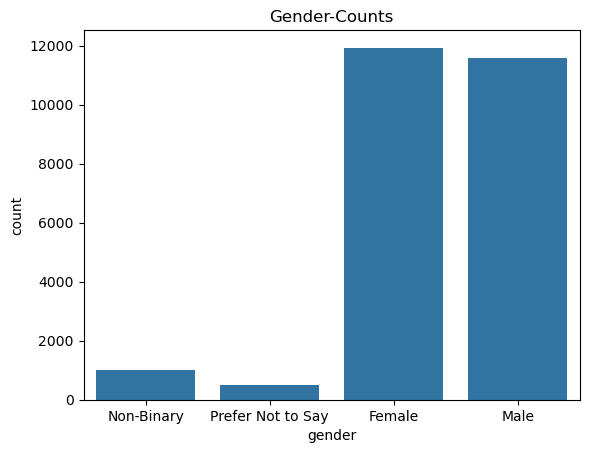

In [258]:
sns.countplot(x=df['gender'])
plt.title('Gender-Counts')
plt.show()

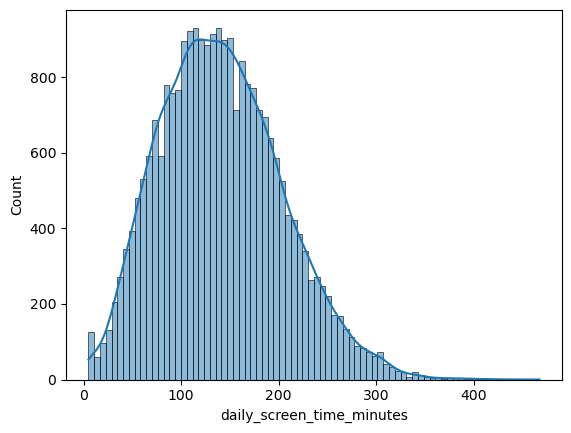

In [260]:
sns.histplot(x=df['daily_screen_time_minutes'], kde=True) 
plt.show()

<Axes: >

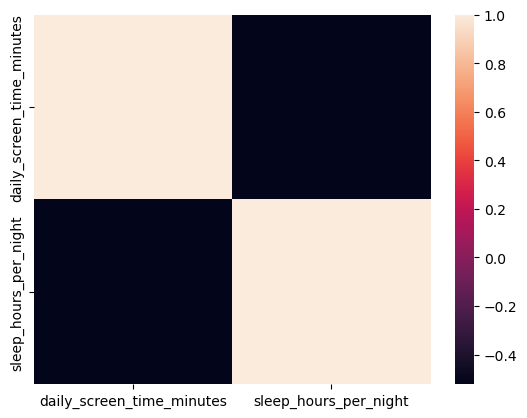

In [261]:
corr = df[['daily_screen_time_minutes', 'sleep_hours_per_night']].corr()
sns.heatmap(corr)

# Task 2: Data Preprocessing

In [193]:
# Encoding

In [194]:
df.columns.to_list()

['user_id',
 'age',
 'age_group',
 'gender',
 'country',
 'occupation',
 'education_level',
 'income_bracket',
 'relationship_status',
 'primary_platform',
 'num_platforms_used',
 'daily_screen_time_minutes',
 'weekly_sessions',
 'avg_session_duration_minutes',
 'preferred_content_type',
 'primary_device',
 'usage_purpose',
 'posts_per_week',
 'likes_per_day',
 'comments_per_day',
 'shares_per_week',
 'followers_count',
 'following_count',
 'engagement_rate_pct',
 'video_consumption_daily_minutes',
 'has_purchased_via_social',
 'follows_influencers',
 'ad_click_frequency',
 'monthly_social_spending_usd',
 'uses_privacy_settings',
 'experienced_cyberbullying',
 'reports_fake_news_frequency',
 'self_reported_mental_health_effect',
 'sleep_hours_per_night',
 'addiction_level_1_to_10',
 'productivity_impact',
 'platform_satisfaction',
 'account_created_date',
 'account_age_years',
 'is_verified_account',
 'is_content_creator',
 'uses_ai_features',
 'daily_notifications',
 'checks_phone_fir

In [195]:
col_for_dummie = ['gender', 'relationship_status', 'primary_platform', 
                  'preferred_content_type', 'primary_device', 'usage_purpose',
                  'occupation']

In [196]:
col_for_label = ['country']

In [197]:
col_for_ordinal = ['age_group', 'education_level', 'income_bracket',
                   'ad_click_frequency', 'reports_fake_news_frequency', 
                   'productivity_impact', 'platform_satisfaction','self_reported_mental_health_effect']

In [198]:
col_for_true_false = ['has_purchased_via_social', 'follows_influencers',
                      'uses_privacy_settings', 'experienced_cyberbullying', 
                     'is_verified_account', 'is_content_creator', 'uses_ai_features',
                      'checks_phone_first_morning', 'uses_screen_time_limits']

In [199]:
# get_dummies
df = pd.get_dummies(df,columns=col_for_dummie, drop_first=True, dtype=np.int32)

In [200]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [201]:
le = LabelEncoder()

In [202]:
df['country']=le.fit_transform(df['country'])

In [203]:
# Ordinal_Encoding
oe = OrdinalEncoder(categories=[
                                    ['13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'],  # -> age_group
                                    ['High School or Below','Some College','Vocational/Trade',"Bachelor's Degree",
                                    "Master's Degree",'Doctoral/Professional'],  # -> education
                                    ['< $10K','$10K-$25K','$25K-$50K','$50K-$75K','$75K-$100K','$100K-$150K','$150K+'], # income_bracket 
                                    ['Never','Rarely','Sometimes','Often'],  # ad_click_frequency
                                    ['Never','Rarely','Sometimes','Often'],  # reports_fake_news_frequency 
                                    ['Decreased', 'No Change', 'Increased'],  # productivity_impact
                                    ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'],  # platform_satisfaction
                                    ['Negative', 'Mostly Negative', 'Neutral', 'Mostly Positive', 'Positive'],  # self_reported_mental_health_effect
                               ]
                   )

In [204]:
df[col_for_ordinal] = oe.fit_transform(df[col_for_ordinal])

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Columns: 103 entries, user_id to occupation_Unemployed
dtypes: bool(9), float64(13), int32(65), int64(14), object(2)
memory usage: 11.9+ MB


In [206]:
df.select_dtypes(include='object').columns

Index(['user_id', 'account_created_date'], dtype='object')

In [207]:
df.drop(columns=['user_id', 'account_created_date'], inplace=True)